In [1]:
%matplotlib inline

import math
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import amjuel
import ehr
import xsection as xs

We first use the H collisional radiative code, *collrad*, to model the fate of the products of dissociative excitation of H$_{2}$:

$\frac{N_{n}}{n_{H_{2}}} = - (Q^{-1})_{nm} E_{H_{2},m} \equiv R_{H}^{H_{2}}(p)$.

For a detailed explanation of the H CR model, see the DEGAS 2 User's Manual.  In the initial implementation of the above expression, these products were specified via reactions in Janev, Langer, Evans and Post (JLEP):

$E_{H_{2},m} = [< \sigma v>_{(2.2.6)} + 2< \sigma v>_{(2.2.7)}, < \sigma v>_{(2.2.8)}, 0, ... 0 ... ]$.

The key step towards most closely reproducing the effective H$_{2}$ rates from AMJUEL is to replace these with the corresponding set computed via Sawada's subroutine, providing values for all $n$.

Using the notation from Kotov's thesis, the **effective dissociation ionization rate for H$_{2}$** is:

$I_{H_{2}} = S(H_{2}^{+}(X^{2}\Sigma_{g}^{+},\Sigma_{u}^{+})) + \sum_{p^{\prime} > 1}S_{H}(p^{\prime}) R_{H}^{H_{2}}(p^{\prime})$,

where $S(H_{2}^{+}(X^{2}\Sigma_{g}^{+},\Sigma_{u}^{+})) = < \sigma v>_{(2.2.10)}$ is the familiar rate for dissociative excitation and $S_{H}(p^{\prime})$ represents the rate of ionization from H state $p^{\prime}$.  The latter is the array *cien* in the collrad code; note that the initial entry in this array represents the ground state, not $n=2$, as is the case for *gam*, i.e., the quantity $\gamma(p^{\prime})$ used in setting up the effective dissociation rate.

Unlike the effective dissociation rate, we have a handle on both terms in the above expression for $I_{H_{2}}$ and can use the effective rates computed by *collrad* directly.  However, we will compare with the corresponding dissociative ionization rate from AMJUEL for reference purposes.

First, read in the data from the *collrad* model:

In [2]:
h2cr_19_saw = ehr.ehr_data('fort.19')
print(h2cr_19_saw.data_dict.keys())

dict_keys(['  H2 Dissociation Rate(jt,jn) (cm**3 s**-1)  Te(jt) = 10**(-1.2 + (jt-1)/10) jt=1,60\n', '  H2 Dissociative Ionization Rate(jt,jn) (cm**3 s**-1)\n', '  H2+ Dissociative Recombination Rate(jt,jn)  (cm**3 s**-1)\n', '  H2+ Dissociation Rate(jt,jn)  (cm**3 s**-1)\n', '  H2+ Dissociative Ionization Rate(jt,jn)  (cm**3 s**-1)\n', '  H2 Dissociative Excitation n=3 / n=1 (jt,jn)\n', '  H2+ Dissociative Excitation n=3 / n=1 (jt,jn)\n', '  H2+ Dissociative Recombination n=3 / n=1 (jt,jn)\n', '  H2 Dissociative Excitation n=2 / n=1 (jt,jn)\n', '  H2+ Dissociative Excitation n=2 / n=1 (jt,jn)\n', '  H2+ Dissociative Recombination n=2 / n=1 (jt,jn)\n', ' H2 Dissociative Excitation n=4 / n=1 (jt,jn)\n', ' H2+ Dissociative Excitation n=4 / n=1 (jt,jn)\n', ' H2+ Dissociative Recombination n=4 / n=1 (jt,jn)\n', ' H2 Dissociative Excitation n=5 / n=1 (jt,jn)\n', ' H2+ Dissociative Excitation n=5 / n=1 (jt,jn)\n', ' H2+ Dissociative Recombination n=5 / n=1 (jt,jn)\n', ' H2 Dissociative Excit

In [3]:
I_H2_saw = h2cr_19_saw.get_one_var('H2 Dissociative Ionization Rate')

Now read in the data from AMJUEL:

In [4]:
amj_file = 'amjuel.tex'

Use the same grid for the two sets of data.

In [5]:
ehr19Te = h2cr_19_saw.get_Te()
ehr19ne = h2cr_19_saw.get_ne()
num_Te = ehr19Te.shape[0]
num_ne = ehr19ne.shape[0]

In [6]:
H123 = 'H.4'
reacstr = '2.2.10'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
data_2210 = np.zeros((num_ne,num_Te))
for jt in range(num_Te):
    for jn in range(num_ne):
        data_2210[jn,jt] = amjuel.ne_Te_exp_fit(fit_coef,ehr19ne[jn],ehr19Te[jt])

We will be comparing with the reaction rate previously used by DEGAS 2 for this process.  This was obtained by evaluation of the fit for the JLEP reaction (2.2.10):

In [7]:
data_dir = '../'
h2dision_nc = xs.xs_netCDF.read_ncfile('h2dision',data_dir)
h2dision_nc.xs.list_vars()
print('  ')
h2dision_nc.xs.print_var(0)
old_rate = h2dision_nc.xs.get_var4plot(0)
print('  ')
h2dision_nc.xs.print_var(2)
old_eloss = h2dision_nc.xs.get_var4plot(2)

 j              Name                   Units     
 0 reaction_rate                  cm^3/s         
 1 dissociation_energy            eV             
 2 background_energy_loss_rate    eV*cm^3/s      
  
Dependent variable:  reaction_rate  Units:  cm^3/s 
 Multiplier:  1.00000e-06  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04
  
Dependent variable:  background_energy_loss_rate  Units:  eV*cm^3/s 
 Multiplier:  1.60218e-25  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04


Make the comparison plot.

The designation "JCR" here and in the name of this and the other associated molecular dissociation reaction files stands for "Janev Collisional Radiative" since the original approach was to use the Janev rates for the dissociative excitation product distribution in *collrad*.

The lines labeled "JCR Saw" refer to the output obtained from the *collrad* code with the Sawada subroutine for the dissociative excitation product distribution.  

The previous DEGAS 2 rate for this process, without collisional radiative effects, is included for comparison.  Again, this is lower at higher $T_{e}$ since it lacks contributions from the decay or de-excitation of dissociative excitation products.

The different colors represent different densities, as is indicated by the legend.

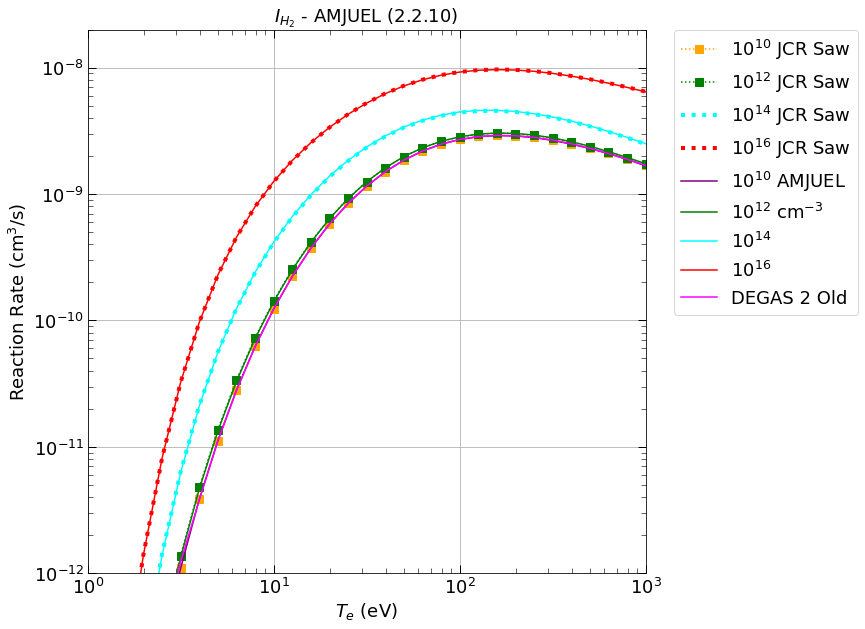

In [8]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,I_H2_saw[0,:],'-s',markersize=8,label='$10^{10}$ JCR Saw',ls=':',color='orange')
plt.plot(ehr19Te,I_H2_saw[4,:],'-s',markersize=8,label='$10^{12}$ JCR Saw',ls=':',color='green')
plt.plot(ehr19Te,I_H2_saw[8,:],markersize=8,label='$10^{14}$ JCR Saw',lw=4,ls=':',color='cyan')
plt.plot(ehr19Te,I_H2_saw[12,:],markersize=8,label='$10^{16}$ JCR Saw',lw=4,ls=':',color='red')
plt.plot(ehr19Te,data_2210[0,:],label='$10^{10}$ AMJUEL',color='purple')
plt.plot(ehr19Te,data_2210[4,:],label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,data_2210[8,:],label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,data_2210[12,:],label='$10^{16}$',color='red')
plt.plot(old_rate[0],old_rate[1],label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_xlim((1.,1.e3))
plt.gca().set_ylim((1.e-12,2.e-8))
plt.gca().grid(axis='both',which='major')
plt.title('$I_{H_{2}}$ - AMJUEL (2.2.10)',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

The JLEP data for reaction (2.2.10) involves two intermediate states with different thresholds, as well as different energies for the products.  The authors provide a staged prescription for the electron energies:

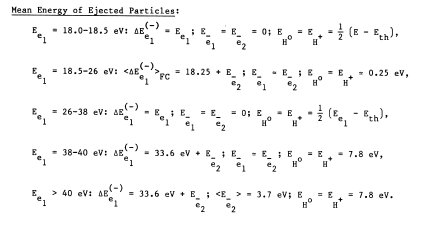

Note that the threshold energies for the two states are 18.0 and 26.0 eV.

We transform this into a nearly linear prescription for the dissociation energy in terms of electron temperatures as:

In [9]:
num_T_E_diss = 10
T_e_E_diss = np.array([17.+np.float(i) for i in range(num_T_E_diss)])
E_diss = np.array([3.75 + 0.75*np.float(i) for i in range(num_T_E_diss)])
E_diss[0] = 0.25
E_diss[-1] = 7.8
print(T_e_E_diss)
print(E_diss)

[17. 18. 19. 20. 21. 22. 23. 24. 25. 26.]
[0.25 4.5  5.25 6.   6.75 7.5  8.25 9.   9.75 7.8 ]


The electron cooling rate per reaction is handled in a simpler fashion: 18.5 eV for $T_{e} < 17$ eV and 33.6 eV for $T_{e} > 31$ eV, scaling as $1.5 T_{e}$ in between:

In [10]:
E_loss_rate = np.zeros(num_Te)
for i in range(num_Te):
    if (ehr19Te[i] < 17.0):
        E_loss_rate[i] = 18.5*I_H2_saw[0,i]
    elif (ehr19Te[i] > 31.0):
        E_loss_rate[i] = 33.6*I_H2_saw[0,i]
    else:
        E_loss_rate[i] = 1.5*ehr19Te[i]*I_H2_saw[0,i]

Compare this loss rate with the one previously used by DEGAS 2 for this reaction:

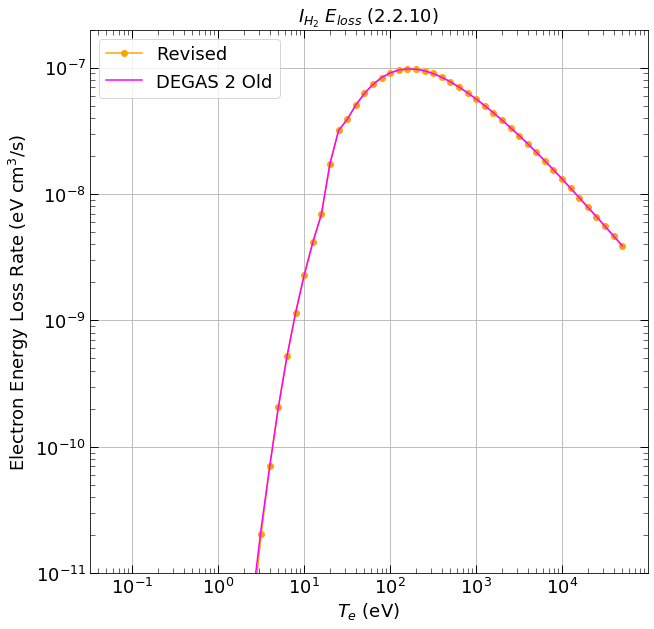

In [11]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,E_loss_rate[:],'-o',
         label='Revised',color='orange')
plt.plot(old_eloss[0],old_eloss[1],label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Electron Energy Loss Rate (eV cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
#plt.gca().set_xlim((1.,1.e3))
plt.gca().set_ylim((1.e-11,2.e-7))
plt.gca().grid(axis='both',which='major')
plt.title('$I_{H_{2}}$ $E_{loss}$ (2.2.10)',fontsize=18)
plt.legend(fontsize=18)

Writing the data to the netCDF file consists of two steps.  The first involves defining the independent and dependent variables and then setting up the data table that holds all of the actual rate data.

The variables being written to this file are: 

0. Reaction rate(temperature,density)
1. Dissociation energy (temperature)
2. Background energy loss rate (temperature)

As above, there are num_ne density values and num_Te temperature values.   Note that we change from using (density,temperature)  in these notebooks to (temperature,density) in the netCDF files.  The swap is effected by sending the transpose of the data array in the set_data method call below. 

This initialization call sets the name of the reaction and the netCDF file, and specifies the number of dependent variables.

In [12]:
h2dision = xs.xs_data('h2dision_jcr',3)

Now, loop through the variables, providing the name, evaluation name (not really used), dimensions, units, multiplier, independent variable minimum and maximum, and the spacing method used for interpolation.

In [13]:
h2dision.set_var(0,['reaction_rate','temperature','density'],'table',
              [num_Te,num_ne],['cm^3/s','eV','cm^-3'],
              [1.e-6,xs.electron_charge,1.e6],
              [ehr19Te[0],ehr19ne[0]],
              [ehr19Te[-1],ehr19ne[-1]],
              ['log']*3)

In [14]:
h2dision.set_var(1,['dissociation_energy','temperature'],'table_external',
              [num_T_E_diss],['eV','eV'],
              [xs.electron_charge,xs.electron_charge],
              [T_e_E_diss[0]],
              [T_e_E_diss[-1]],
              ['linear']*2)

In [15]:
h2dision.set_var(2,['background_energy_loss_rate','temperature'],'table_external',
              [num_Te],['eV*cm^3/s','eV'],
              [1.e-6*xs.electron_charge,xs.electron_charge],
              [ehr19Te[0]],
              [ehr19Te[-1]],
              ['log']*2)

Fill in the data table:

In [16]:
h2dision.set_data(0,I_H2_saw.T)
h2dision.set_data(1,E_diss)
h2dision.set_data(2,E_loss_rate)

Now open the netCDF file, write in the data using the h2dision xs_data data structures, and close the file.

In [17]:
work_dir = './'
h2dision_nc = xs.xs_netCDF.write_ncfile(h2dision,work_dir,
                       'Reference atomic physics data for a reaction in degas 2',
                       'V. 1.0, effective H2 dissociative ionization with CR effects')
h2dision_nc.close()